In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
bf_fake = pd.read_json("/content/buzzfeed_fake.json", lines=True)
bf_real = pd.read_json("/content/buzzfeed_real.json", lines=True)
bf_fake["label"] = 1
bf_real["label"] = 0

In [ ]:
bf_df = pd.concat([pf_fake, pf_real], ignore_index=True)

In [ ]:
bf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   top_img         209 non-null    object
 1   text            240 non-null    object
 2   authors         209 non-null    object
 3   keywords        209 non-null    object
 4   meta_data       209 non-null    object
 5   canonical_link  209 non-null    object
 6   images          209 non-null    object
 7   title           240 non-null    object
 8   url             209 non-null    object
 9   summary         209 non-null    object
 10  movies          209 non-null    object
 11  publish_date    164 non-null    object
 12  source          209 non-null    object
 13  label           240 non-null    int64 
dtypes: int64(1), object(13)
memory usage: 26.4+ KB


In [ ]:
df = bf_df.sample(frac=1).reset_index(drop=True)

In [ ]:
# Drop rows with missing text
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip().astype(bool)]

# Reset index
df = df.reset_index(drop=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Install required packages
!pip install textstat spacy gensim
!python -m spacy download en_core_web_sm

#  Imports
import pandas as pd
import spacy
import textstat
import nltk
import re
from nltk.corpus import words as nltk_words
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import gensim.downloader as api
import numpy as np

nltk.download("words")
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
nlp.add_pipe("sentencizer")
english_vocab = set(nltk_words.words())
from gensim.models import KeyedVectors

w2v_model = KeyedVectors.load_word2vec_format(
    "/content/drive/MyDrive/word2vec-google-news-300/GoogleNews-vectors-negative300.bin.gz",
    binary=True
)

#w2v_model = api.load("word2vec-google-news-300")  # takes time

#  Utility: Count syllables safely
def safe_syllable(word):
    try:
        return textstat.syllable_count(word)
    except:
        return 0

#  Word2Vec mean vector for a given text
def get_mean_w2v_vector(text):
    words = [w for w in text.lower().split() if w in w2v_model]
    if words:
        return np.mean([w2v_model[w] for w in words], axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

#  Core feature extractor (57 + 300 features)
def extract_57_plus_w2v(text):
    doc = nlp(text)
    words = [token.text for token in doc if token.is_alpha]
    sentences = list(doc.sents)
    tokens = [token.text.lower() for token in doc]

    num_words = len(words)
    num_syllables = sum(safe_syllable(w) for w in words)
    num_sentences = len(sentences)
    big_words = sum(1 for w in words if len(w) > 6)
    short_sents = sum(1 for s in sentences if len(s.text.split()) <= 5)
    long_sents = sum(1 for s in sentences if len(s.text.split()) >= 20)
    syllables_per_word = num_syllables / num_words if num_words else 0

    try:
        fk_grade = textstat.flesch_kincaid_grade(text)
    except:
        fk_grade = 0
    avg_words_per_sentence = num_words / num_sentences if num_sentences else 0
    sentence_complexity = sum(s.text.count(',') + s.text.count(';') for s in sentences) / num_sentences if num_sentences else 0

    pos_counts = Counter([token.pos_ for token in doc])
    tag_counts = Counter([token.tag_ for token in doc])
    word_counts = Counter([token.text.lower() for token in doc if token.is_alpha])
    total_tokens = len(doc)

    dict_words = [w.lower() for w in words if w.lower() in english_vocab]
    num_dict_words = len(dict_words)
    pct_dict_words = 100 * num_dict_words / num_words if num_words else 0
    pct_long_words = 100 * big_words / num_words if num_words else 0

    pronouns = ["PRP", "PRP$", "WP", "WP$"]
    first_person = ["i", "me", "my", "mine"]
    first_person_pl = ["we", "us", "our", "ours"]
    third_person = ["he", "she", "they", "them", "his", "her", "their"]

    def count_pct(tokens, match_list):
        count = sum(1 for tok in tokens if tok.lower() in match_list)
        return 100 * count / num_words if num_words else 0

    negation_words = ["not", "no", "never", "n't"]
    modal_verbs = ["can", "could", "should", "would", "might", "must", "may", "shall"]
    conjunctions = ["and", "or", "but", "because", "since", "although"]
    affective_terms = ["happy", "sad", "angry", "fear", "joy", "hate", "love"]

    features = {
        "f1_num_syllables": num_syllables,
        "f2_num_words": num_words,
        "f3_num_sentences": num_sentences,
        "f4_big_words": big_words,
        "f5_syllables_per_word": syllables_per_word,
        "f6_short_sentences": short_sents,
        "f7_long_sentences": long_sents,
        "f8_flesch_kincaid": fk_grade,
        "f9_avg_words_per_sentence": avg_words_per_sentence,
        "f10_sentence_complexity": sentence_complexity,
        "f11_num_conjunctions": sum(1 for w in tokens if w in conjunctions),
        "f12_emotiveness": count_pct(tokens, affective_terms),
        "f13_adj_adv_rate": (pos_counts["ADJ"] + pos_counts["ADV"]) / num_words if num_words else 0,
        "f14_affective_terms": sum(1 for w in tokens if w in affective_terms),
        "f15_pct_dict_words": pct_dict_words,
        "f16_pct_long_words": pct_long_words,
        "f17_pct_total_pronouns": count_pct(tokens, pronouns),
        "f18_pct_first_person_singular": count_pct(tokens, first_person),
        "f19_pct_first_person_total": count_pct(tokens, first_person + first_person_pl),
        "f20_pct_third_person": count_pct(tokens, third_person),
        "f21_pct_negations": count_pct(tokens, negation_words),
        "f22_pct_articles": count_pct(tokens, ["a", "an", "the"]),
        "f23_pct_prepositions": pos_counts["ADP"] / num_words * 100 if num_words else 0,
        "f24_positive_emotion": text.count("happy") + text.count("joy"),
        "f25_negative_emotion": text.count("sad") + text.count("angry") + text.count("hate"),
        "f26_cognitive": text.count("think") + text.count("know") + text.count("believe"),
        "f27_causation": text.count("because") + text.count("due to"),
        "f28_insight": text.count("realize") + text.count("understand"),
        "f29_discrepancy": text.count("should") + text.count("would"),
        "f30_tentative": text.count("maybe") + text.count("perhaps"),
        "f31_certainty": text.count("definitely") + text.count("certainly"),
        "f32_sensory": text.count("see") + text.count("hear"),
        "f33_social": text.count("friend") + text.count("family"),
        "f34_space": text.count("around") + text.count("near"),
        "f35_inclusive": text.count("and") + text.count("with"),
        "f36_exclusive": text.count("but") + text.count("without"),
        "f37_motion_verbs": sum(1 for tok in doc if tok.lemma_ in ["go", "move", "run", "walk"]),
        "f38_time": text.count("when") + text.count("time"),
        "f39_past_verb": tag_counts["VBD"],
        "f40_present_verb": tag_counts["VBP"] + tag_counts["VBZ"],
        "f41_future_verb": sum(1 for i in range(len(tokens)-1) if tokens[i] == "will" and tokens[i+1].startswith("v")),
        "f42_num_noun_phrases": len(list(doc.noun_chunks)),
        "f43_avg_clauses": pos_counts["VERB"] / num_sentences if num_sentences else 0,
        "f44_avg_word_length": sum(len(w) for w in words) / num_words if num_words else 0,
        "f45_avg_np_length": sum(len(np) for np in doc.noun_chunks) / len(list(doc.noun_chunks)) if doc.noun_chunks else 0,
        "f46_pausality": sum(1 for tok in doc if tok.is_punct) / num_sentences if num_sentences else 0,
        "f47_modifiers": pos_counts["ADJ"] + pos_counts["ADV"],
        "f48_modal_verbs": sum(1 for w in tokens if w in modal_verbs),
        "f49_passive_voice": sum(1 for tok in doc if tok.dep_ == "auxpass"),
        "f50_objectification": sum(1 for w in tokens if w in ["thing", "object"]),
        "f51_general_terms": sum(1 for w in tokens if w in ["everyone", "everything"]),
        "f52_group_ref": sum(1 for w in tokens if w in ["we", "us", "our"]),
        "f53_lexical_diversity": len(set(words)) / num_words if num_words else 0,
        "f54_content_word_diversity": len(set(w for w in words if len(w) > 3)) / num_words if num_words else 0,
        "f55_redundancy": sum(1 for w in tokens if w in spacy.lang.en.stop_words.STOP_WORDS) / num_sentences if num_sentences else 0,
        "f56_typo_ratio": sum(1 for w in words if w.lower() not in english_vocab) / num_words if num_words else 0,
        "f57_spatiotemporal": sum(1 for w in tokens if w in ["today", "yesterday", "now", "here", "there"]),
    }

    #  Append Word2Vec vector (300 dims)
    w2v_vector = get_mean_w2v_vector(text)
    for i, val in enumerate(w2v_vector):
        features[f"w2v_{i}"] = val

    return features


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

def extract_all_features_parallel(df, text_col="text", max_workers=4):
    texts = df[text_col].tolist()
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        features = list(tqdm(executor.map(extract_57_plus_w2v, texts), total=len(texts), desc="Extracting features"))
    return pd.DataFrame(features)

In [ ]:
df_features = extract_all_features_parallel(df, text_col="text", max_workers=4)
df_features["label"] = df["label"]  # ✅ Now safe to add

Extracting features:   0%|          | 0/238 [00:00<?, ?it/s]

In [ ]:
df_features.info()
df_features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Columns: 358 entries, f1_num_syllables to label
dtypes: float32(300), float64(23), int64(35)
memory usage: 386.9 KB


,f1_num_syllables,f2_num_words,f3_num_sentences,f4_big_words,f5_syllables_per_word,f6_short_sentences,f7_long_sentences,f8_flesch_kincaid,f9_avg_words_per_sentence,f10_sentence_complexity,...,w2v_291,w2v_292,w2v_293,w2v_294,w2v_295,w2v_296,w2v_297,w2v_298,w2v_299,label
0,239,159,8,33,1.503145,1,3,11.0,19.875000,0.875000,...,-0.021335,-0.072533,0.046824,-0.009897,0.002562,-0.023510,-0.057519,0.047915,-0.041972,0
1,338,228,11,50,1.482456,0,8,10.2,20.727273,0.454545,...,-0.003556,-0.047617,0.039731,-0.005757,0.022348,-0.013152,-0.019941,0.026397,-0.044506,1
2,600,407,24,87,1.474201,1,9,8.5,16.958333,0.458333,...,0.025207,-0.105640,0.021824,-0.039105,-0.012932,0.006906,-0.042461,0.051848,-0.026220,0
3,356,235,11,48,1.514894,1,6,10.5,21.363636,0.727273,...,0.047648,-0.076681,0.030435,-0.048712,0.006421,-0.003488,-0.053855,0.026781,-0.029945,1
4,451,288,21,77,1.565972,3,4,8.9,13.714286,0.476190,...,0.033125,-0.063096,0.025652,-0.045751,-0.025191,0.031253,-0.063446,0.032809,-0.022340,1


In [ ]:
import pandas as pd
df_features=pd.read_csv("buzzfeed_357_features.csv")

In [ ]:
X = df_features.drop(columns=["label"])
y = df_features["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

 Performing Hyperparameter Tuning with Cross-Validation...

Tuning k-NN...
Tuning Decision Tree...
Tuning Naive Bayes...
Tuning SVM...
Tuning AdaBoost...
Tuning Bagging...

 Final Results Summary:

        Model                                                 Best Parameters CV Accuracy (Mean) Test Accuracy
         k-NN {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}             0.7632        0.7917
Decision Tree {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}             0.7211        0.7500
  Naive Bayes                                                  {'alpha': 0.1}             0.7105        0.7708
          SVM                                      {'C': 10, 'kernel': 'rbf'}             0.7842        0.7917
     AdaBoost                     {'learning_rate': 0.1, 'n_estimators': 150}             0.7947        0.7500
      Bagging  {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 150}             0.7368        0.8333


<ipython-input-6-bf4a71f2dfd1>:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="CV Accuracy", data=cv_df, palette="Set2")


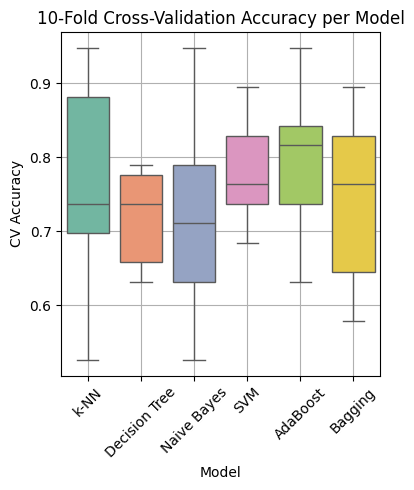

<ipython-input-6-bf4a71f2dfd1>:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test Accuracy", data=test_df, palette="Set3")


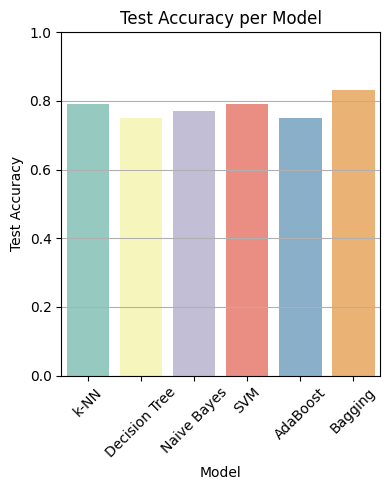

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier

# Define models
models = {
    "k-NN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": BernoulliNB(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

# Define parameter grids
param_grids = {
    "k-NN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Decision Tree": {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Naive Bayes": {
        'alpha': [0.1, 1.0, 10.0]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    "Bagging": {
        'n_estimators': [50, 100, 150],
        'max_samples': [ 0.7],
        'max_features': [0.5]
    }
}

# Stratified K-Fold
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores_all = []   # to collect all fold-wise CV scores
test_accuracies = [] # to collect test accuracies
final_results = []   # to display final results

print(" Performing Hyperparameter Tuning with Cross-Validation...\n")
for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=kfold, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    # 10-fold CV scores using best model
    fold_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')
    for score in fold_scores:
        cv_scores_all.append({'Model': name, 'CV Accuracy': score})

    # Test accuracy
    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    test_accuracies.append({'Model': name, 'Test Accuracy': test_accuracy})

    final_results.append({
        "Model": name,
        "Best Parameters": grid_search.best_params_,
        "CV Accuracy (Mean)": f"{np.mean(fold_scores):.4f}",
        "Test Accuracy": f"{test_accuracy:.4f}"
    })

# Convert to DataFrames
cv_df = pd.DataFrame(cv_scores_all)
test_df = pd.DataFrame(test_accuracies)
summary_df = pd.DataFrame(final_results)

# Print final summary
print("\n Final Results Summary:\n")
print(summary_df.to_string(index=False))

# === Plot 1: CV Accuracy Box Plot ===
plt.figure(figsize=(4, 5))
sns.boxplot(x="Model", y="CV Accuracy", data=cv_df, palette="Set2")
plt.title("10-Fold Cross-Validation Accuracy per Model")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot 2: Test Accuracy Bar Plot ===
plt.figure(figsize=(4, 5))
sns.barplot(x="Model", y="Test Accuracy", data=test_df, palette="Set3")
plt.title("Test Accuracy per Model")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
